In [2]:
# import Libraries & Load Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set visualization style
sns.set_theme(style="whitegrid")

# Exact file path from your computer
file_path = r"C:\Users\User\Favorites\Downloads\empty\seasonal_agriculture_performance_dataset.csv"

# Load dataset
df = pd.read_csv(file_path)
print("Data loaded successfully!")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Data loaded successfully!
Dataset Shape: 4000 rows, 28 columns


In [3]:
#Data Cleaning & Exploratory Data Analysis (EDA)

# General inspection
print("--- DATASET OVERVIEW ---")
print(df.info())

print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

print("\n--- DUPLICATE ROWS ---")
print(f"Duplicates count: {df.duplicated().sum()}")

# Summary statistics
print("\n--- STATISTICAL SUMMARY ---")
display(df.describe().T)

--- DATASET OVERVIEW ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha         

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [4]:
#Seasonal Performance Analysis

# 1. Environmental Conditions Across Seasons
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_Moisture_pct']
print("--- MEAN ENVIRONMENTAL CONDITIONS BY SEASON ---")
display(df.groupby('Season')[env_cols].mean().round(2))

# 2. Economic Metrics Across Seasons
econ_cols = ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR']
print("\n--- MEAN ECONOMIC PERFORMANCE BY SEASON ---")
display(df.groupby('Season')[econ_cols].mean().round(2))

# 3. Resource Usage Across Seasons
resource_cols = ['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3']
print("\n--- MEAN RESOURCE USAGE BY SEASON ---")
display(df.groupby('Season')[resource_cols].mean().round(2))

--- MEAN ENVIRONMENTAL CONDITIONS BY SEASON ---


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,852.08,28.45,71.81,6.79,31.20
Rabi,436.00,23.49,57.89,7.59,24.05
Zaid,299.42,31.04,52.01,8.18,19.17



--- MEAN ECONOMIC PERFORMANCE BY SEASON ---


,Yield_Tonnes_Ha,Production_Tonnes,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,,,
Kharif,5.64,46.31,531804.41,710719.06,178914.65
Rabi,5.08,41.49,513836.58,601526.05,87689.47
Zaid,4.67,38.89,543976.73,519171.90,-24804.82



--- MEAN RESOURCE USAGE BY SEASON ---


,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,
Kharif,187.08,5.08,6102.20,5.89
Rabi,185.41,5.02,5846.99,5.19
Zaid,184.64,5.17,6419.89,4.41


C:\Users\User\AppData\Local\Temp\ipykernel_9908\3722866097.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Season', y='Profit_INR', hue='Crop', ci=None, palette='viridis')


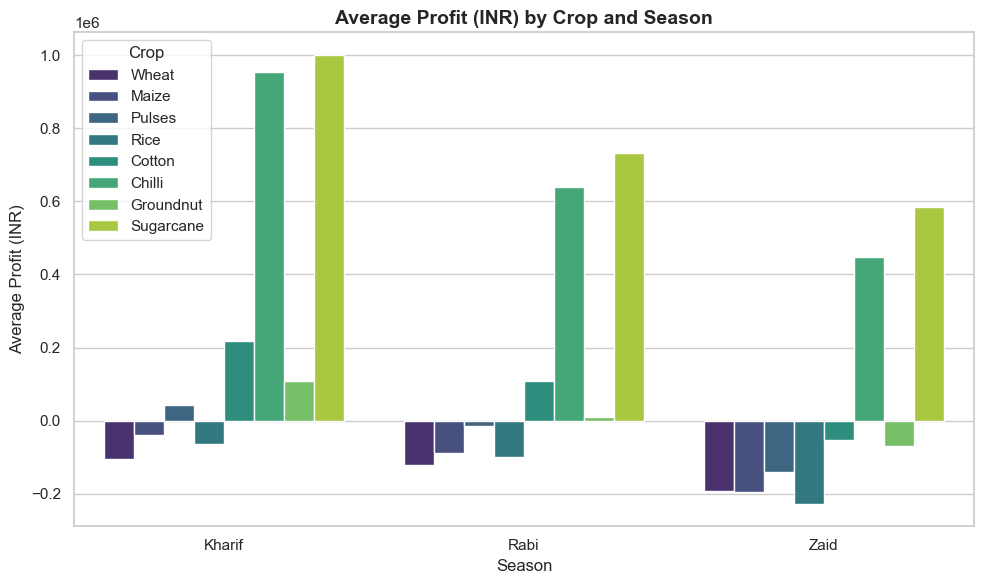

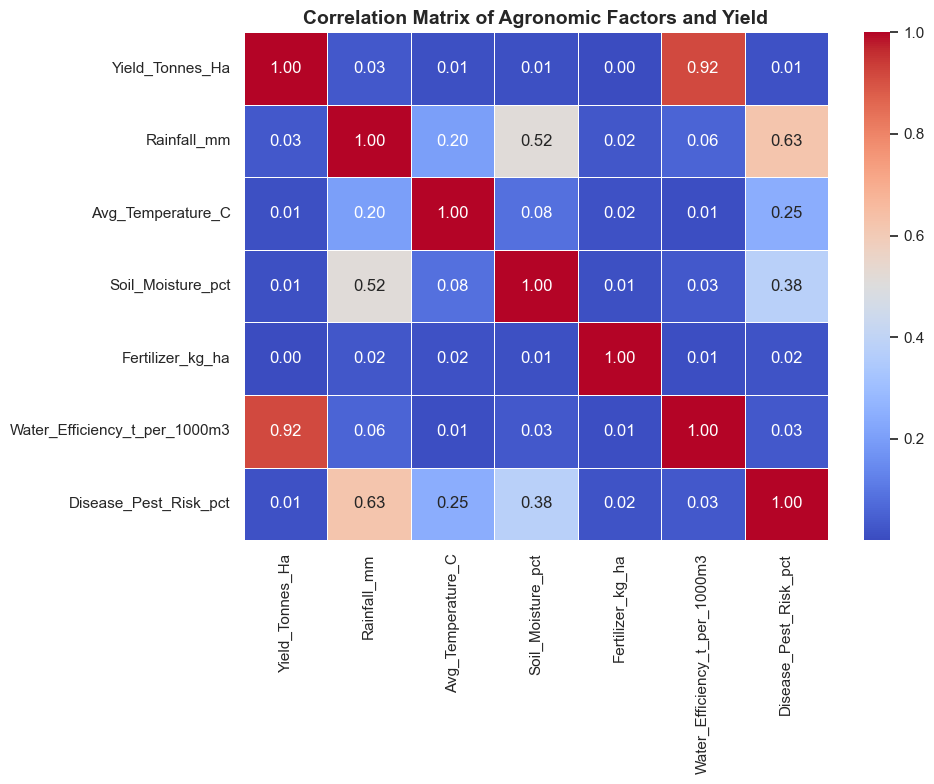

C:\Users\User\AppData\Local\Temp\ipykernel_9908\3722866097.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', palette='Set2')


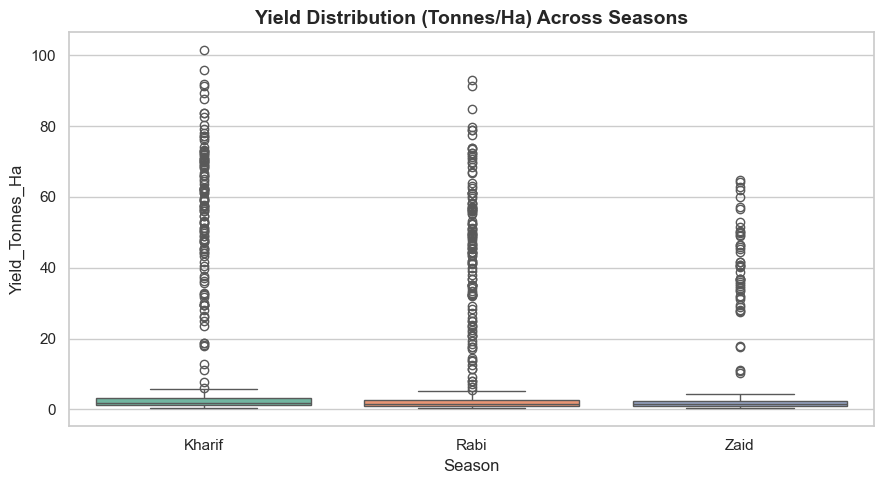

In [5]:
#Data Visualizations

# 1. Seasonal Profitability by Crop
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Season', y='Profit_INR', hue='Crop', ci=None, palette='viridis')
plt.title('Average Profit (INR) by Crop and Season', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.legend(title='Crop')
plt.tight_layout()
plt.show()

# 2. Correlation Matrix of Key Metrics
plt.figure(figsize=(10, 8))
corr_cols = ['Yield_Tonnes_Ha', 'Rainfall_mm', 'Avg_Temperature_C', 'Soil_Moisture_pct', 
             'Fertilizer_kg_ha', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Agronomic Factors and Yield', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Yield Distribution across Seasons
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', palette='Set2')
plt.title('Yield Distribution (Tonnes/Ha) Across Seasons', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
#Hypothesis Testing (ANOVA)

# One-Way ANOVA Test: Check if Yield differs significantly across seasons
seasons = df['Season'].unique()
season_groups = [df[df['Season'] == season]['Yield_Tonnes_Ha'] for season in seasons]

f_stat, p_val = stats.f_oneway(*season_groups)

print("--- ONE-WAY ANOVA TEST (Yield across Seasons) ---")
print(f"F-Statistic: {f_stat:.4f}")
print(f"p-Value    : {p_val:.4e}")

if p_val < 0.05:
    print("\nResult: Significant difference in crop yields between different seasons (p < 0.05).")
else:
    print("\nResult: No statistically significant difference in crop yields across seasons.")

--- ONE-WAY ANOVA TEST (Yield across Seasons) ---
F-Statistic: nan
p-Value    : nan

Result: No statistically significant difference in crop yields across seasons.
